<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [8]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [9]:
import matplotlib.pyplot as plt 

#### Read the dataset in the csv file from the URL


In [14]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [15]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


<h2>Task 2: Generate Descriptive Statistics and Visualizations</h2> 

<h4>a) For the "Median value of owner-occupied homes" provide a boxplot</h4>

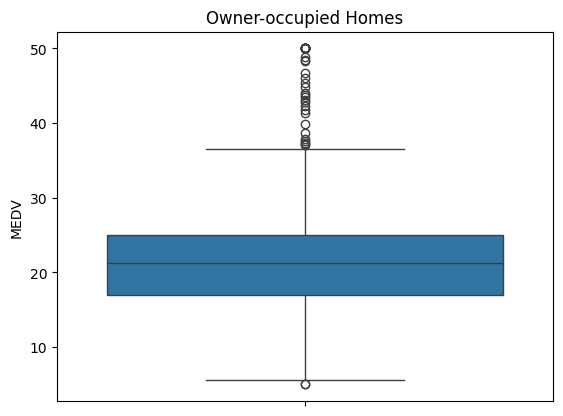

In [16]:
ax = sns.boxplot(y='MEDV', data=boston_df)

ax.set_title('Owner-occupied Homes')
plt.show()

<h4>b) Provide a bar plot for the Charles river variable</h4>

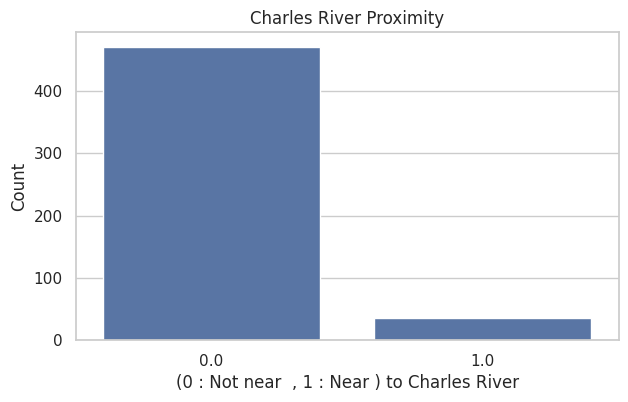

In [19]:
plt.figure(figsize=(7,4))
sns.countplot(x=boston_df['CHAS'])
plt.title("Charles River Proximity")
plt.xlabel("(0 : Not near  , 1 : Near ) to Charles River")
plt.ylabel("Count")
plt.show()     

<h4>c) Provide a boxplot for the MEDV variable vs the AGE variable. (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)</h4>

In [22]:
boston_df.loc[(boston_df['AGE'] <= 35), 'age_group'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35)&(boston_df['AGE'] < 70), 'age_group'] = 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'age_group'] = '70 years and older'

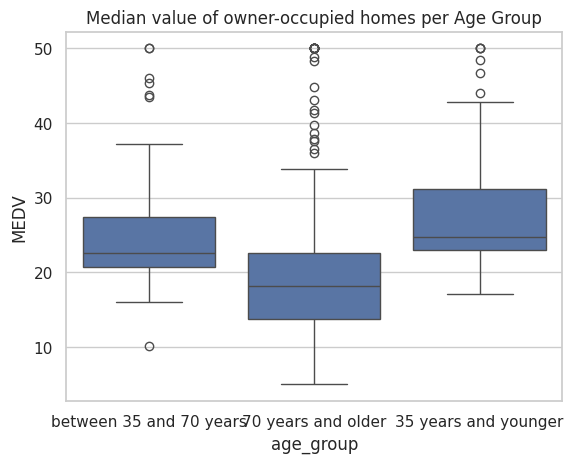

In [23]:
ax3 = sns.boxplot(x='age_group', y="MEDV", data=boston_df)
ax3.set_title('Median value of owner-occupied homes per Age Group')
plt.show()

<h4>d) Provide a scatter plot to show the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town. What can you say about the relationship?</h4>

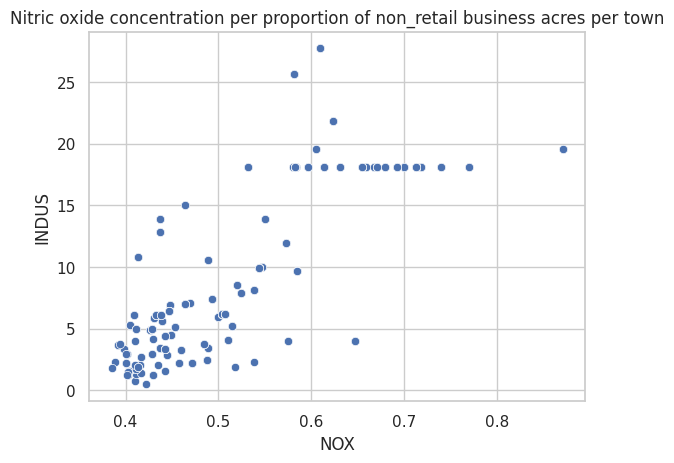

In [24]:
ax4 = sns.scatterplot(x="NOX", y="INDUS", data=boston_df)
ax4.set_title('Nitric oxide concentration per proportion of non_retail business acres per town')
plt.show()

<h4>e) Create a histogram for the pupil to teacher ratio variable</h4>

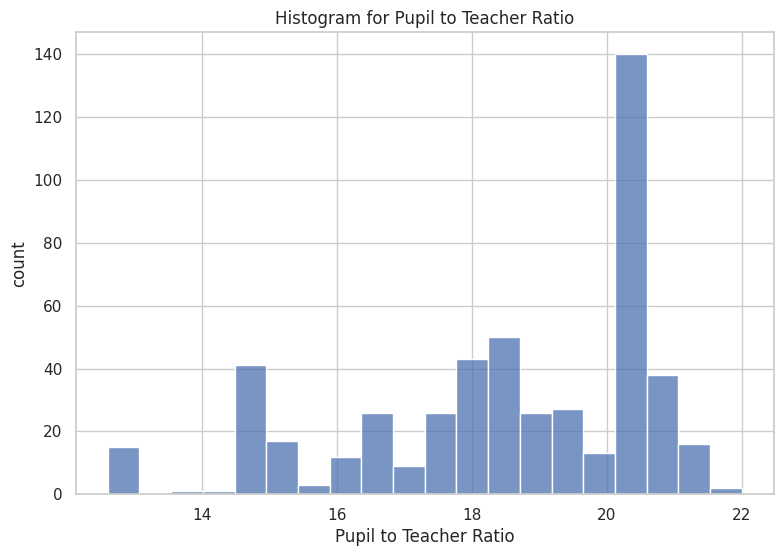

In [25]:
plt.figure(figsize=(9,6))
sns.histplot(boston_df['PTRATIO'], bins=20, kde=False)
plt.title("Histogram for Pupil to Teacher Ratio")
plt.xlabel("Pupil to Teacher Ratio")
plt.ylabel("count")
plt.show()

<h2>Task 3: Use the appropriate tests to answer the questions provided.</h2>

<h4>a) Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)</h4>

H₀ (null hypothesis): There is no significant difference in the median home values between houses located by the Charles River (CHAS=1) and those that are not (CHAS=0).

H₁ (alternative hypothesis): There is a significant difference in the median home values between these two groups.

In [26]:
from scipy.stats import ttest_ind
group1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
group0 = boston_df[boston_df['CHAS'] == 0]['MEDV']
# t_stat, p_value = ttest_ind(group1, group0, equal_var=False) 

t_stat, p_value = scipy.stats.ttest_ind(group1, group0, equal_var=True)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 3.9964
P-value: 0.0001


In [27]:
alpha = 0.05

if p_value < alpha:
    print("We reject H₀: There is a significant difference in MEDV based on CHAS.")
else:
    print("We do not reject H₀: There is no significant difference in MEDV based on CHAS.")

We reject H₀: There is a significant difference in MEDV based on CHAS.


<h4>b) Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)? (ANOVA)</h4>

H₀ (null hypothesis): The means of MEDV are equal for all groups of AGE.

H₁ (alternative hypothesis): At least one of the means of MEDV is different.

In [29]:
boston_df.loc[(boston_df['AGE'] <= 35), 'age_group'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35)&(boston_df['AGE'] < 70), 'age_group'] = 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'age_group'] = '70 years and older'

scipy.stats.levene(boston_df[boston_df['age_group'] == '35 years and younger']['MEDV'],
                   boston_df[boston_df['age_group'] == 'between 35 and 70 years']['MEDV'],
                    boston_df[boston_df['age_group'] == '70 years and older']['MEDV'],
                     center='mean')

LeveneResult(statistic=2.7806200293748304, pvalue=0.06295337343259205)

Since the p-value is more than alpha value 0.05, we fail to reject the null hypothesis as there is a difference in median value of houses for each proportion of owner occupied units.

<h4>c) Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? (Pearson Correlation)</h4>

H₀ (null hypothesis): There is no linear correlation between the two variables.

H₁ (alternative hypothesis): There is a significant linear correlation between the two variables.

In [30]:
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=0.7636514469209192, pvalue=7.913361061210442e-98)

Since the p-value is more than alpha value 0.05, we reject the null hypothesis as there is a relationship between Nitric oxide concentrations and proportion of non-retail business acres per town.

<h4>d) What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes? (Regression analysis)</h4>

In [32]:
import statsmodels.api as sm

X = boston_df['DIS']
y = boston_df['MEDV']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 23 May 2025   Prob (F-statistic):           1.21e-08
Time:                        14:08:48   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

<h4>Since the coef DIS is 1.0916, we can say that an additional weighted distance to the five employment centers in boston increases of 1.0916 the median value of owner occupied homes</h4>